In [15]:
!pip install yfinance scikit-learn hmmlearn matplotlib

In [16]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt

In [17]:

data = yf.download(
    "^NSEI",
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)
# Flatten MultiIndex columns
data.columns = data.columns.get_level_values(0)
# Convert Date index to normal column
data = data.reset_index()
# Remove column index name
data.columns.name = None
# Sort by date
data = data.sort_values("Date").reset_index(drop=True)
# Save clean dataset
data.to_csv("clean_data.csv", index=False)
data.head()


[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


In [18]:

# Calculate log returns
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)
# 20-day rolling volatility
data["Volatility"] = data["Log_Return"].rolling(window=20).std()
# Range Feature
data["Range"] = (
    data["High"] - data["Low"]
) / data["Close"]
# # 20-Day Momentum
# data["Momentum"] = (
#     data["Close"] /
#     data["Close"].shift(20)
# ) - 1
# Remove NaN values created by rolling window
data = data.dropna().reset_index(drop=True)


In [19]:
features = data[[
    "Date",
    "Log_Return",
    "Volatility",
    "Range",
    "Close",
]].copy()

features.to_csv("features.csv", index=False)


In [20]:
X = features[
    ["Log_Return",
     "Volatility",
     "Range",
     ]
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(3909, 3)


In [21]:
def calculate_aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

def calculate_bic(log_likelihood, n_params, n_samples):
    return np.log(n_samples) * n_params - 2 * log_likelihood

In [22]:
def count_hmm_parameters(n_states, n_features):

    transition_params = n_states * (n_states - 1)

    start_params = n_states - 1

    mean_params = n_states * n_features

    covariance_params = n_states * n_features

    total = (
        transition_params
        + start_params
        + mean_params
        + covariance_params
    )

    return total

In [23]:
results = []

models = {}

for n_states in range(2, 7):

    print(f"\nTraining {n_states} states...")

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=1000,
        random_state=42
    )

    model.fit(X_scaled)

    log_likelihood = model.score(X_scaled)

    n_params = count_hmm_parameters(
        n_states=n_states,
        n_features=X_scaled.shape[1]
    )

    aic = calculate_aic(
        log_likelihood,
        n_params
    )

    bic = calculate_bic(
        log_likelihood,
        n_params,
        len(X_scaled)
    )

    hidden_states = model.predict(X_scaled)

    counts = pd.Series(hidden_states).value_counts()

    results.append({
        "States": n_states,
        "LogLikelihood": log_likelihood,
        "AIC": aic,
        "BIC": bic,
        "MinStateSize": counts.min(),
        "MaxStateSize": counts.max()
    })

    models[n_states] = {
        "model": model,
        "states": hidden_states
    }


Training 2 states...

Training 3 states...

Training 4 states...

Training 5 states...

Training 6 states...


In [24]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="BIC"
)

comparison

,States,LogLikelihood,AIC,BIC,MinStateSize,MaxStateSize
4,6,-7891.152553,15924.305106,16369.548723,78,883
3,5,-8479.965381,17067.930762,17406.566753,92,1115
2,4,-9357.299296,18792.598593,19037.169030,87,1376
1,3,-10523.738875,21099.477749,21262.524708,667,1741
0,2,-12506.213144,25042.426289,25136.491842,1148,2761


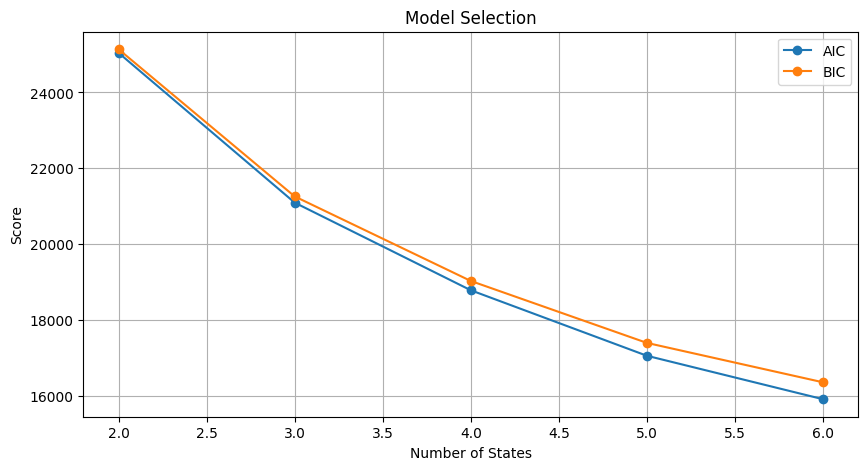

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    comparison["States"],
    comparison["AIC"],
    marker="o",
    label="AIC"
)

plt.plot(
    comparison["States"],
    comparison["BIC"],
    marker="o",
    label="BIC"
)

plt.xlabel("Number of States")
plt.ylabel("Score")

plt.title("Model Selection")

plt.legend()

plt.grid(True)

plt.show()

In [26]:
for n_states in range(2, 7):

    print("\n")
    print("="*50)
    print(f"{n_states} STATES")
    print("="*50)

    model = models[n_states]["model"]

    trans = model.transmat_

    durations = []

    for i in range(n_states):

        p = trans[i, i]

        duration = 1 / (1 - p)

        durations.append(duration)

    duration_df = pd.DataFrame({
        "State": range(n_states),
        "ExpectedDuration": durations
    })

    print(duration_df)



2 STATES
   State  ExpectedDuration
0      0         34.128636
1      1         14.203465


3 STATES
   State  ExpectedDuration
0      0         22.151099
1      1         13.354816
2      2         40.997778


4 STATES
   State  ExpectedDuration
0      0         37.553354
1      1         18.693168
2      2          4.853700
3      3         28.106754


5 STATES
   State  ExpectedDuration
0      0         33.019981
1      1          4.116405
2      2         18.265454
3      3         26.435746
4      4         15.265417


6 STATES
   State  ExpectedDuration
0      0         13.423681
1      1         12.166977
2      2         11.136339
3      3         21.098757
4      4          7.011684
5      5         26.894765


In [27]:
for n_states in range(2, 7):

    print("\n")
    print("="*60)
    print(f"STATE CHARACTERISTICS : {n_states}")
    print("="*60)

    temp = X.copy()

    temp["State"] = models[n_states]["states"]

    summary = temp.groupby("State").agg({
        "Log_Return": ["mean", "std"],
        "Volatility": ["mean", "std"],
        "Range": ["mean", "std"]
    })

    print(summary)



STATE CHARACTERISTICS : 2
      Log_Return           Volatility               Range          
            mean       std       mean       std      mean       std
State                                                              
0       0.000770  0.007025   0.007385  0.001798  0.009316  0.003769
1      -0.000393  0.015854   0.013955  0.006107  0.017694  0.011361


STATE CHARACTERISTICS : 3
      Log_Return           Volatility               Range          
            mean       std       mean       std      mean       std
State                                                              
0       0.000458  0.009113   0.009542  0.001404  0.011741  0.004757
1      -0.000386  0.018418   0.016104  0.007232  0.019996  0.013690
2       0.000756  0.006031   0.006034  0.000982  0.008165  0.003198


STATE CHARACTERISTICS : 4
      Log_Return           Volatility               Range          
            mean       std       mean       std      mean       std
State                           

In [28]:
for n_states in range(2, 7):

    print("\n")
    print("="*50)
    print(f"{n_states} STATES")
    print("="*50)

    counts = pd.Series(
        models[n_states]["states"]
    ).value_counts()

    percentages = (
        counts / counts.sum() * 100
    )

    balance_df = pd.DataFrame({
        "Count": counts,
        "Percent": percentages
    })

    print(balance_df)



2 STATES
   Count    Percent
0   2761  70.631875
1   1148  29.368125


3 STATES
   Count    Percent
0   1741  44.538245
2   1501  38.398567
1    667  17.063188


4 STATES
   Count    Percent
0   1376  35.200819
1   1361  34.817089
3   1085  27.756459
2     87   2.225633


5 STATES
   Count    Percent
4   1115  28.523919
2   1069  27.347148
0    984  25.172678
3    649  16.602712
1     92   2.353543


6 STATES
   Count    Percent
2    883  22.588897
1    826  21.130724
0    811  20.746994
5    729  18.649271
3    582  14.888718
4     78   1.995395
